# Predict Next Month MRR with scikit-learn

Goal: predict `total_mrr_next_month`, meaning the total recurring revenue expected next month based on what is known this month.

For this dataset, the label needs to be created because the CSV has monthly MRR and customer/revenue movement columns, but it does not already contain `total_mrr_next_month`.

In [0]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [0]:
TARGET = "total_mrr_next_month"

## 2. Load and inspect the data

The most important rule here is to sort by `month`. Since this is time series data, model validation should respect time order.

In [0]:
CSV_PATH = "/Volumes/datalake_catalog/datalake_schema/silver_draft/mrr/part-00000-tid-1842690682545798514-2c34c718-5a14-4cee-a40e-f2512b458be6-3008-1-c000.csv"
df = pd.read_csv(CSV_PATH)
df["month"] = pd.to_datetime(df["month"], utc=True).dt.tz_localize(None)
df = df.sort_values("month").reset_index(drop=True)

print(df.shape)
display(df.head())
display(df.tail())
display(df.dtypes)

(62, 15)


month,num_tickets,num_churn,num_renewals,current_mrr,new_mrr,expansion_mrr,contraction_mrr,churned_mrr,active_subscriptions,num_conversions,num_upgrades,num_downgrades,initial,num_enterprise
2023-02-01T00:00:00.000Z,42,8,276,44763.60666666665,35840.29666666665,2160.1608333333334,1160.0108333333335,1856.41,735,2,6,1,0,167
2023-03-01T00:00:00.000Z,79,26,581,97263.76500000004,59968.70333333333,9792.575,4279.45,12981.669999999998,1538,6,13,5,5,379
2023-04-01T00:00:00.000Z,96,71,882,155984.00166666685,81469.63083333333,22096.80583333333,12915.56,31930.639999999992,2312,5,28,24,13,519
2023-05-01T00:00:00.000Z,127,173,1111,222025.8875000005,110249.65333333336,21962.622499999998,22212.31833333333,43958.07166666666,3262,19,52,32,25,678
2023-06-01T00:00:00.000Z,128,240,1492,281890.71416666725,114180.05333333336,35581.13083333333,30315.536666666656,59580.82083333333,4301,14,51,42,36,812


month,num_tickets,num_churn,num_renewals,current_mrr,new_mrr,expansion_mrr,contraction_mrr,churned_mrr,active_subscriptions,num_conversions,num_upgrades,num_downgrades,initial,num_enterprise
2027-11-01T00:00:00.000Z,116,122,0,36060.70083333333,0.0,7.105427357601002E-15,761.6149999999999,11853.38583333333,463,0,16,9,6,0
2027-12-01T00:00:00.000Z,120,85,0,22371.260833333326,0.0,0.0,2632.585,11056.855,289,0,11,4,4,0
2028-01-01T00:00:00.000Z,103,34,0,9694.66583333333,0.0,0.0,853.5233333333333,11823.071666666669,147,0,3,2,2,0
2028-02-01T00:00:00.000Z,84,14,0,4986.6225,0.0,0.0,110.82499999999996,4597.218333333332,75,0,1,0,2,0
2028-03-01T00:00:00.000Z,86,8,0,1543.3808333333332,0.0,0.0,11.840000000000032,3431.401666666667,22,0,0,0,0,0


month                   datetime64[ns]
num_tickets                      int64
num_churn                        int64
num_renewals                     int64
current_mrr                    float64
new_mrr                        float64
expansion_mrr                  float64
contraction_mrr                float64
churned_mrr                    float64
active_subscriptions             int64
num_conversions                  int64
num_upgrades                     int64
num_downgrades                   int64
initial                          int64
num_enterprise                   int64
dtype: object

In [0]:
print("Date range:", df["month"].min().date(), "to", df["month"].max().date())
print("Duplicate months:", df["month"].duplicated().sum())
display(df.isna().sum().to_frame("missing_values"))

Date range: 2023-02-01 to 2028-03-01
Duplicate months: 0


missing_values
0
0
0
0
0
0
0
0
0
0


## 3. Create the label column

Create `total_mrr_next_month`.

Why: supervised learning needs historical pairs like:

`this month's behavior and revenue movement -> next month's total MRR`

The label for each row is the following month's `current_mrr`. The final month will have no known next month, so it is not used for training. It can still be used as the row we forecast from.

In [0]:
def add_next_month_label(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    data["month"] = pd.to_datetime(data["month"], utc=True).dt.tz_localize(None)
    data = data.sort_values("month").reset_index(drop=True)

    future = data[["month", "current_mrr"]].copy()
    future["month"] = future["month"] - pd.DateOffset(months=1)
    future = future.rename(columns={"current_mrr": TARGET})

    return data.merge(future, on="month", how="left")


labeled = add_next_month_label(df)
display(labeled[["month", "current_mrr", TARGET]].head(10))
display(labeled[["month", "current_mrr", TARGET]].tail(10))

month,current_mrr,total_mrr_next_month
2023-02-01T00:00:00.000Z,44763.60666666665,97263.76500000004
2023-03-01T00:00:00.000Z,97263.76500000004,155984.00166666685
2023-04-01T00:00:00.000Z,155984.00166666685,222025.8875000005
2023-05-01T00:00:00.000Z,222025.8875000005,281890.71416666725
2023-06-01T00:00:00.000Z,281890.71416666725,364974.1925000005
2023-07-01T00:00:00.000Z,364974.1925000005,460025.6941666674
2023-08-01T00:00:00.000Z,460025.6941666674,531311.388333334
2023-09-01T00:00:00.000Z,531311.388333334,630740.726666667
2023-10-01T00:00:00.000Z,630740.726666667,721740.2533333335
2023-11-01T00:00:00.000Z,721740.2533333335,859972.7416666668


month,current_mrr,total_mrr_next_month
2027-06-01T00:00:00.000Z,149252.6000000002,118320.74666666682
2027-07-01T00:00:00.000Z,118320.74666666682,91834.9633333334
2027-08-01T00:00:00.000Z,91834.9633333334,65689.3841666667
2027-09-01T00:00:00.000Z,65689.3841666667,48675.70166666668
2027-10-01T00:00:00.000Z,48675.70166666668,36060.70083333333
2027-11-01T00:00:00.000Z,36060.70083333333,22371.260833333326
2027-12-01T00:00:00.000Z,22371.260833333326,9694.66583333333
2028-01-01T00:00:00.000Z,9694.66583333333,4986.6225
2028-02-01T00:00:00.000Z,4986.6225,1543.3808333333332
2028-03-01T00:00:00.000Z,1543.3808333333332,null


`df[TARGET] = df["current_mrr"].shift(-1)` after sorting by month. The merge method above is a little safer because it explicitly aligns by calendar month.

## 4. Add modeling features

These engineered features use only information available in the current month. Avoid adding anything from next month, because that would leak the answer into the model.

In [0]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    month_num = data["month"].dt.month
    data["month_sin"] = np.sin(2 * np.pi * month_num / 12)
    data["month_cos"] = np.cos(2 * np.pi * month_num / 12)

    data["net_mrr_movement"] = (
        data["new_mrr"]
        + data["expansion_mrr"]
        - data["contraction_mrr"]
        - data["churned_mrr"]
    )
    data["gross_positive_mrr"] = data["new_mrr"] + data["expansion_mrr"]
    data["gross_negative_mrr"] = data["contraction_mrr"] + data["churned_mrr"]

    data["churn_rate_by_subs"] = data["num_churn"] / data["active_subscriptions"].replace(0, np.nan)
    data["upgrade_rate_by_subs"] = data["num_upgrades"] / data["active_subscriptions"].replace(0, np.nan)
    data["downgrade_rate_by_subs"] = data["num_downgrades"] / data["active_subscriptions"].replace(0, np.nan)

    return data


model_df = add_features(labeled)
trainable = model_df.dropna(subset=[TARGET]).copy()
latest_unlabeled = model_df[model_df[TARGET].isna()].tail(1).copy()

feature_cols = [
    col
    for col in trainable.columns
    if col not in {"month", TARGET} and pd.api.types.is_numeric_dtype(trainable[col])
]

print("Trainable rows:", len(trainable))
print("Forecast row month:", latest_unlabeled["month"].iloc[0].date() if len(latest_unlabeled) else None)
print("Features:")
print(feature_cols)

Trainable rows: 61
Forecast row month: 2028-03-01
Features:
['num_tickets', 'num_churn', 'num_renewals', 'current_mrr', 'new_mrr', 'expansion_mrr', 'contraction_mrr', 'churned_mrr', 'active_subscriptions', 'num_conversions', 'num_upgrades', 'num_downgrades', 'initial', 'num_enterprise', 'month_sin', 'month_cos', 'net_mrr_movement', 'gross_positive_mrr', 'gross_negative_mrr', 'churn_rate_by_subs', 'upgrade_rate_by_subs', 'downgrade_rate_by_subs']


## 5. Define preprocessing and candidate models

For only about 60 monthly observations, start simple and compare against a strong baseline. A complex model is not automatically better here.

In [0]:
def make_preprocessor(features):
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                features,
            )
        ],
        remainder="drop",
    )


def make_models(features):
    preprocessor = make_preprocessor(features)
    return {
        "linear_regression": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
        "ridge": Pipeline([("prep", preprocessor), ("model", Ridge(alpha=10.0))]),
        "elastic_net": Pipeline([
            ("prep", preprocessor),
            ("model", ElasticNet(alpha=0.001, l1_ratio=0.25, max_iter=10000)),
        ]),
        "random_forest": Pipeline([
            ("prep", preprocessor),
            ("model", RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=42)),
        ]),
        "extra_trees": Pipeline([
            ("prep", preprocessor),
            ("model", ExtraTreesRegressor(n_estimators=500, min_samples_leaf=3, random_state=42)),
        ]),
        "gradient_boosting": Pipeline([
            ("prep", preprocessor),
            ("model", GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=42)),
        ]),
        "reliable_lower_bound_p20": Pipeline([
            ("prep", preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    loss="quantile",
                    alpha=0.20,
                    n_estimators=300,
                    learning_rate=0.03,
                    max_depth=2,
                    random_state=42,
                ),
            ),
        ]),
    }

Model notes:

- `baseline_current_mrr`: sanity check; predicts next month equals current month.
- `LinearRegression`: interpretable starting point.
- `Ridge` and `ElasticNet`: usually better for small datasets with correlated columns.
- `RandomForestRegressor`, `ExtraTreesRegressor`, `GradientBoostingRegressor`: nonlinear tabular models.
- `reliable_lower_bound_p20`: estimates a conservative 20th percentile outcome, useful for the phrase "reliably generate".

## 6. Chronological holdout test

Never randomly split this dataset. Use the older months for training and the newest labeled months for testing.

In [0]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), 1e-9)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


X = trainable[feature_cols]
y = trainable[TARGET]

test_size = min(12, max(1, len(trainable) // 5))
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

rows = []

baseline_pred = X_test["current_mrr"].to_numpy()
rows.append({
    "model": "baseline_current_mrr",
    "mae": mean_absolute_error(y_test, baseline_pred),
    "rmse": mean_squared_error(y_test, baseline_pred, squared=False),
    "mape_pct": mape(y_test, baseline_pred),
    "r2": r2_score(y_test, baseline_pred),
})

models = make_models(feature_cols)
predictions = pd.DataFrame({"month": trainable.iloc[-test_size:]["month"], "actual": y_test})

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    rows.append({
        "model": name,
        "mae": mean_absolute_error(y_test, pred),
        "rmse": mean_squared_error(y_test, pred, squared=False),
        "mape_pct": mape(y_test, pred),
        "r2": r2_score(y_test, pred),
    })

holdout_results = pd.DataFrame(rows).sort_values("mae")
display(holdout_results)

/databricks/python/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.166e+09, tolerance: 4.260e+08
  model = cd_fast.enet_coordinate_descent(


model,mae,rmse,mape_pct,r2
ridge,14228.594178418762,20012.987361204134,350.23353647232784,0.9239583929464654
baseline_current_mrr,22989.734930555598,26986.000435492617,61.924826846819,0.861737472894034
elastic_net,30901.408789577396,33089.340496366254,266.1957903626044,0.7921243275784288
linear_regression,36295.61867189416,42459.06431244832,502.61640165361644,0.657730435047343
gradient_boosting,115562.51123065602,122015.0570747336,1204.5418627642143,-1.8265345552868455
reliable_lower_bound_p20,137305.5260942102,142255.96121693062,1256.3454277691358,-2.8420976040010415
extra_trees,146963.22975822995,158005.66855434343,1644.9355093595766,-3.7399392995361893
random_forest,182537.3133236077,196734.19416723275,2117.576816018809,-6.348304526436833


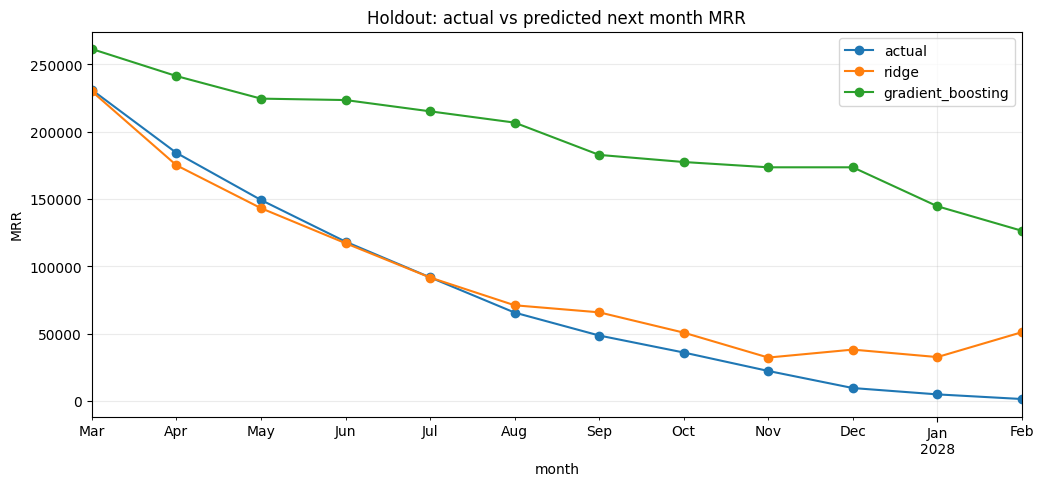

In [0]:
best_model_name = holdout_results.iloc[0]["model"]
plot_cols = ["actual"]
if best_model_name != "baseline_current_mrr":
    plot_cols.append(best_model_name)
plot_cols.append("gradient_boosting") if "gradient_boosting" not in plot_cols else None

predictions.set_index("month")[plot_cols].plot(figsize=(12, 5), marker="o")
plt.title("Holdout: actual vs predicted next month MRR")
plt.ylabel("MRR")
plt.grid(True, alpha=0.25)
plt.show()

## 7. TimeSeriesSplit cross-validation

This gives a broader estimate than a single holdout period, still respecting time order.

In [0]:
n_splits = min(5, max(2, len(trainable) // 12))
cv = TimeSeriesSplit(n_splits=n_splits)

cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
        },
    )
    cv_rows.append({
        "model": name,
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_mae")
display(cv_results)

/databricks/python/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.917e+09, tolerance: 2.829e+08
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.250e+09, tolerance: 3.138e+08
  model = cd_fast.enet_coordinate_descent(
/databricks/python/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.76

model,cv_mae,cv_rmse
ridge,36860.968949800874,42267.41546952999
elastic_net,46920.17219735316,50360.00022843341
gradient_boosting,105054.6225538321,111175.18775923208
linear_regression,134791.91083867545,140614.4347110956
extra_trees,144393.9876446955,150473.09658486795
reliable_lower_bound_p20,149882.5142273841,156938.1411592561
random_forest,152943.16181761315,159992.32146273518


## 8. Forecast the next month

The latest row has no known label, so after choosing a model from validation, fit on all labeled data and predict that latest row's next month.

In [0]:
best_model_name = holdout_results.iloc[0]["model"]

if latest_unlabeled.empty:
    print("No unlabeled latest row found. Add the current month row before forecasting.")
else:
    forecast_month = latest_unlabeled["month"].iloc[0] + pd.DateOffset(months=1)

    if best_model_name == "baseline_current_mrr":
        point_forecast = latest_unlabeled["current_mrr"].iloc[0]
    else:
        best_model = models[best_model_name]
        best_model.fit(X, y)
        point_forecast = best_model.predict(latest_unlabeled[feature_cols])[0]

    lower_bound_model = models["reliable_lower_bound_p20"]
    lower_bound_model.fit(X, y)
    conservative_p20 = lower_bound_model.predict(latest_unlabeled[feature_cols])[0]

    print(f"Forecast month: {forecast_month:%Y-%m}")
    print(f"Best point forecast model: {best_model_name}")
    print(f"Predicted {TARGET}: {point_forecast:,.2f}")
    print(f"Conservative p20 lower-bound estimate: {conservative_p20:,.2f}")

Forecast month: 2028-04
Best point forecast model: ridge
Predicted total_mrr_next_month: 3,929.77
Conservative p20 lower-bound estimate: 30,392.37


## 9. Save the labeled dataset

This is useful for inspecting the target column or reuse the supervised learning table elsewhere.

In [0]:
OUTPUT_PATH = Path("mrr_with_total_mrr_next_month.csv")
model_df.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH.resolve()